SWASTHIKA M 24BAD121
Ratings Data:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Movies Data:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

User-Item Matrix Shape: (610, 9719)

RMSE: 1.9965238759965793
MAE: 1.532546444100367

Top Recommendations for User 1:
title
Die

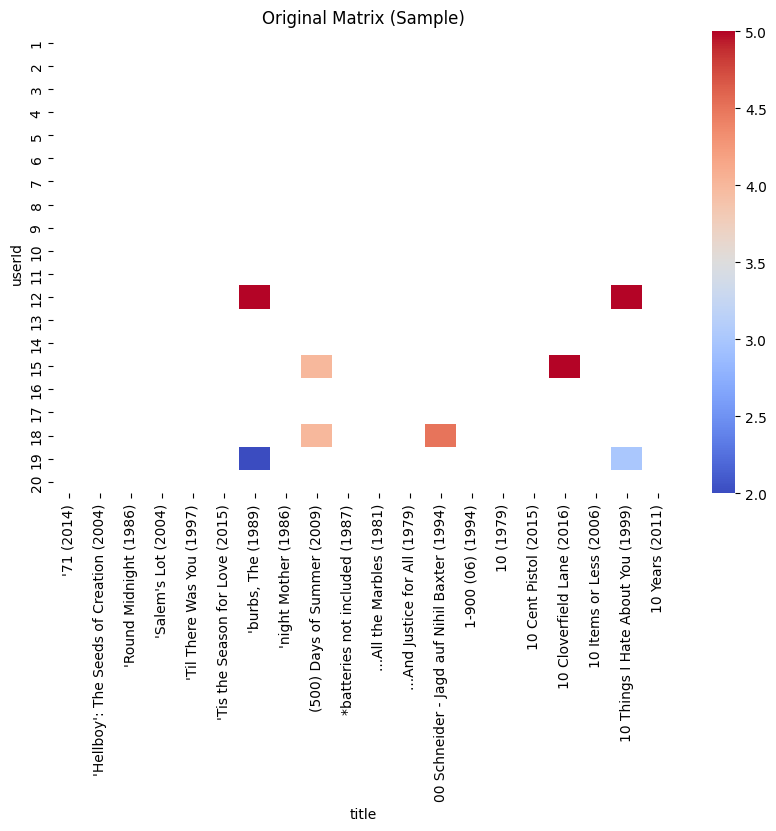

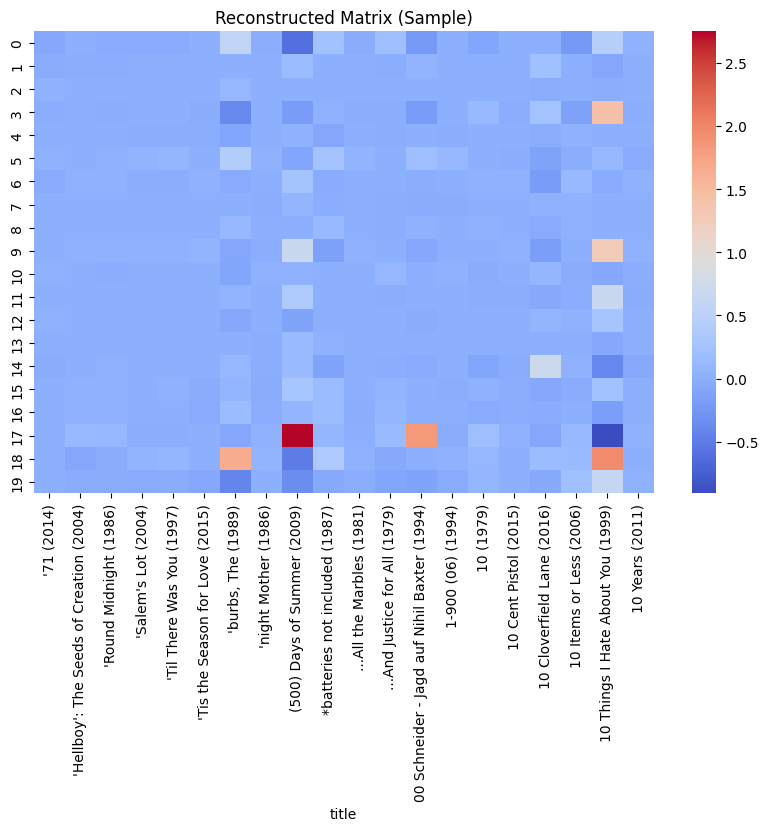

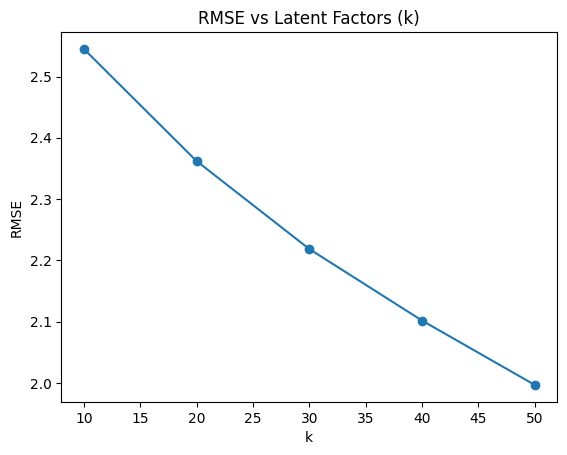

In [4]:
#scenario 1
print("SWASTHIKA M 24BAD121")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")
print("Ratings Data:")
print(ratings.head())

print("\nMovies Data:")
print(movies.head())

# Merge datasets
data = pd.merge(ratings, movies, on="movieId")

# Create User-Item Matrix
user_item_matrix = data.pivot_table(index='userId', columns='title', values='rating')

print("\nUser-Item Matrix Shape:", user_item_matrix.shape)
matrix = user_item_matrix.fillna(0).values

user_mean = np.mean(matrix, axis=1)
matrix_norm = matrix - user_mean.reshape(-1, 1)

k = 50  # latent factors

U, sigma, Vt = svds(matrix_norm, k=k)

# Convert sigma into diagonal matrix
sigma = np.diag(sigma)

predicted_matrix = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)

pred_df = pd.DataFrame(predicted_matrix, columns=user_item_matrix.columns)

# Flatten actual & predicted (only where actual exists)
actual = user_item_matrix.values.flatten()
predicted = pred_df.values.flatten()

# Remove zero entries (missing ratings)
mask = actual > 0
actual = actual[mask]
predicted = predicted[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("\nRMSE:", rmse)
print("MAE:", mae)

def recommend_movies(user_id, num_recommendations=5):
    user_row = pred_df.iloc[user_id - 1]

    sorted_movies = user_row.sort_values(ascending=False)

    # Get already watched movies
    watched = user_item_matrix.iloc[user_id - 1]
    watched_movies = watched[watched > 0].index

    recommendations = sorted_movies.drop(watched_movies).head(num_recommendations)

    return recommendations

# Example
print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

# Heatmap (sample)
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap="coolwarm")
plt.title("Original Matrix (Sample)")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(pred_df.iloc[:20, :20], cmap="coolwarm")
plt.title("Reconstructed Matrix (Sample)")
plt.show()

k_values = [10, 20, 30, 40, 50]
rmse_list = []

for k in k_values:
    U, sigma, Vt = svds(matrix_norm, k=k)
    sigma = np.diag(sigma)
    pred = np.dot(np.dot(U, sigma), Vt) + user_mean.reshape(-1, 1)

    pred_flat = pred.flatten()
    pred_flat = pred_flat[mask]

    rmse_k = np.sqrt(mean_squared_error(actual, pred_flat))
    rmse_list.append(rmse_k)

plt.plot(k_values, rmse_list, marker='o')
plt.title("RMSE vs Latent Factors (k)")
plt.xlabel("k")
plt.ylabel("RMSE")
plt.show()

SWASTHIKA M 24BAD121
Matrix Shape: (610, 9719)


/usr/local/lib/python3.12/dist-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


RMSE: 2.4653908914639038
Precision@5: 0.8
Recall@5: 0.02

Top Recommendations for User 1:
title
Aliens (1986)                             4.242207
Terminator 2: Judgment Day (1991)         4.179159
Star Trek II: The Wrath of Khan (1982)    3.264011
Die Hard (1988)                           3.251964
Sixth Sense, The (1999)                   3.135938
Name: 1, dtype: float64


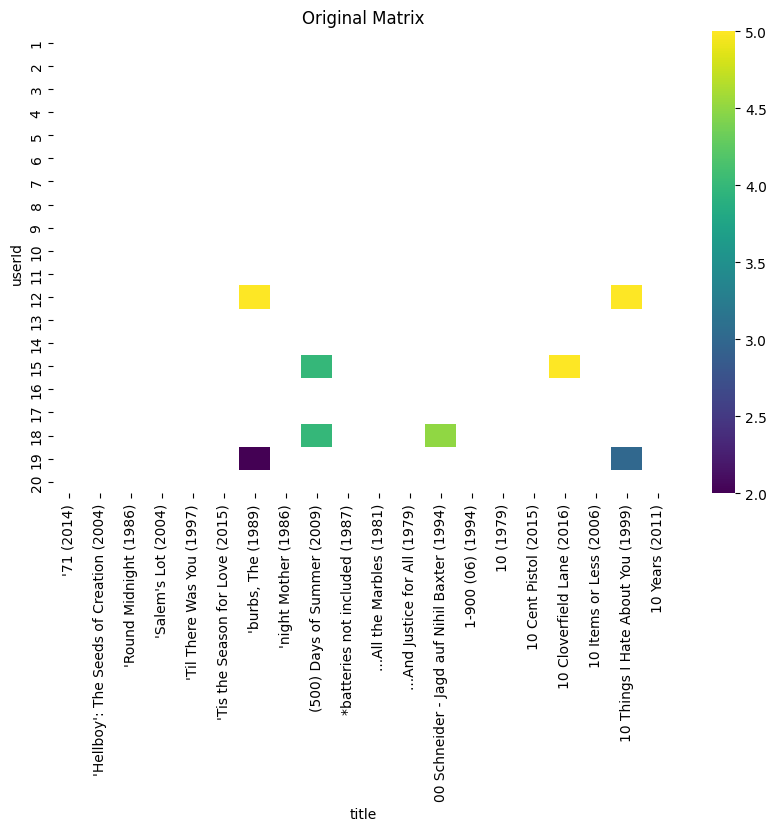

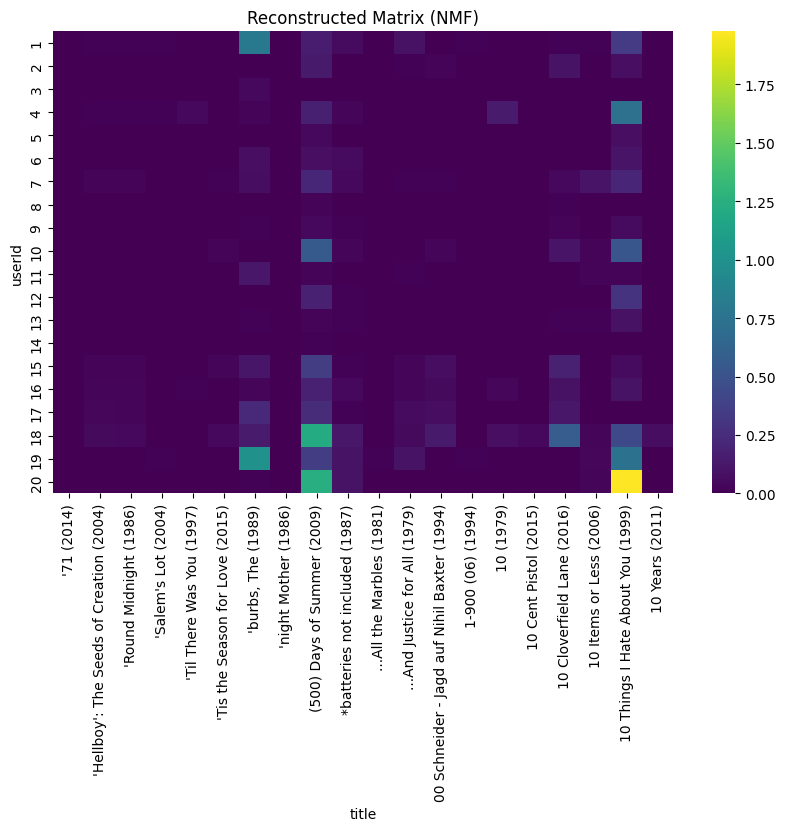

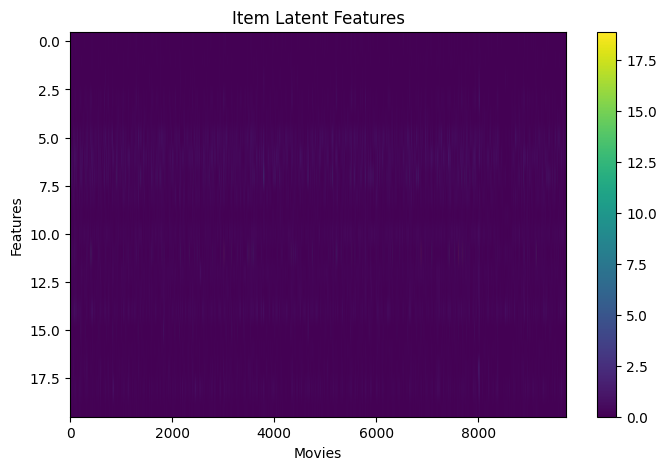

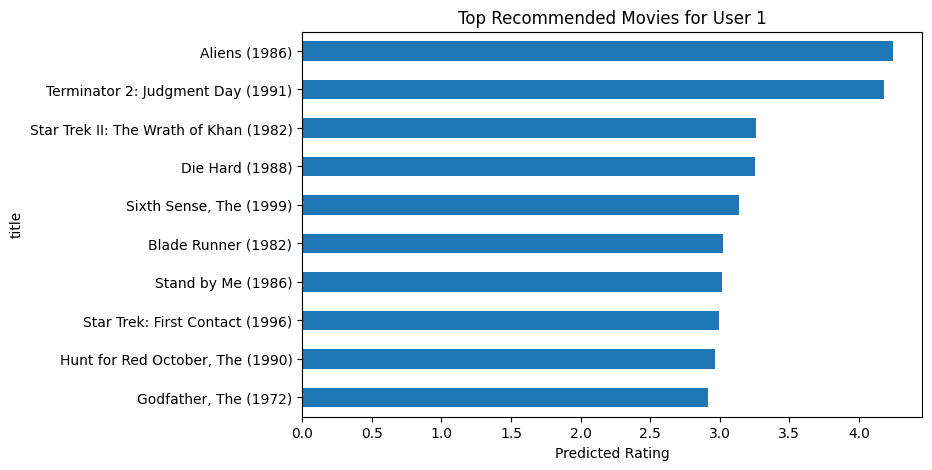

In [5]:
#scenario 2
print("SWASTHIKA M 24BAD121")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics import mean_squared_error

ratings = pd.read_csv("ratings.csv")
movies = pd.read_csv("movies.csv")

# Merge
data = pd.merge(ratings, movies, on="movieId")

user_item_matrix = data.pivot_table(index='userId', columns='title', values='rating')

# Fill missing values with 0
matrix = user_item_matrix.fillna(0)

print("Matrix Shape:", matrix.shape)

k = 20  # latent features

model = NMF(n_components=k, init='random', random_state=42, max_iter=200)

W = model.fit_transform(matrix)   # User-feature matrix
H = model.components_             # Item-feature matrix

reconstructed_matrix = np.dot(W, H)

pred_df = pd.DataFrame(reconstructed_matrix,
                       index=user_item_matrix.index,
                       columns=user_item_matrix.columns)

actual = user_item_matrix.values
predicted = pred_df.values

mask = actual > 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))

print("RMSE:", rmse)

def precision_recall_at_k(user_id, k=5, threshold=3.5):
    user_actual = user_item_matrix.iloc[user_id - 1]
    user_pred = pred_df.iloc[user_id - 1]

    # Relevant items (actual)
    relevant_items = user_actual[user_actual >= threshold].index

    # Top K predicted
    recommended_items = user_pred.sort_values(ascending=False).head(k).index

    # True Positives
    tp = len(set(recommended_items) & set(relevant_items))

    precision = tp / k
    recall = tp / len(relevant_items) if len(relevant_items) > 0 else 0

    return precision, recall

# Example
p, r = precision_recall_at_k(1, 5)
print("Precision@5:", p)
print("Recall@5:", r)

def recommend_movies(user_id, num_recommendations=5):
    user_row = pred_df.iloc[user_id - 1]

    watched = user_item_matrix.iloc[user_id - 1]
    watched_movies = watched[watched > 0].index

    recommendations = user_row.drop(watched_movies).sort_values(ascending=False).head(num_recommendations)

    return recommendations

print("\nTop Recommendations for User 1:")
print(recommend_movies(1, 5))

# Heatmap (sample)
plt.figure(figsize=(10,6))
sns.heatmap(user_item_matrix.iloc[:20, :20], cmap="viridis")
plt.title("Original Matrix")
plt.show()

plt.figure(figsize=(10,6))
sns.heatmap(pred_df.iloc[:20, :20], cmap="viridis")
plt.title("Reconstructed Matrix (NMF)")
plt.show()

plt.figure(figsize=(8,5))
plt.imshow(H, aspect='auto')
plt.colorbar()
plt.title("Item Latent Features")
plt.xlabel("Movies")
plt.ylabel("Features")
plt.show()

top_movies = recommend_movies(1, 10)

plt.figure(figsize=(8,5))
top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Predicted Rating")
plt.show()